<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_13_extendedPAIRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 13 — extended PAIRS: unbinned representations and fast frequentist inference

We start from the controlled misspecification in **Exercise 7** and implement three pieces:

1. Learn an event encoder using singletons and pairs, then freeze it to represent full unbinned experiments.
2. Learn the simulator-to-reference response map with an amortized population fit.
3. Train fast estimator and test-statistic heads on cached full-experiment embeddings.

Each piece has a numerical comparison with the direct unbinned calculation. **This notebook stops before distribution-flow training and Neyman calibration.** Agreement with a likelihood teacher is not a coverage statement.

Our starting point is [PAIRS, *It Just Takes Two*](https://arxiv.org/abs/2605.07972): train a mean-pool encoder at set sizes one and two, freeze it, and train an inference head on full-set embeddings. Here we adapt that strategy to a discrete auxiliary posterior, a population response fit, and frequentist regression heads. These extensions are our prototype, not results established by PAIRS. Its sufficiency theorem does not automatically apply to this finite, imperfectly trained representation. [LF2I](https://arxiv.org/abs/2107.03920) motivates the later separation of statistic learning, calibration, and coverage diagnostics.

This first example has **one signal-strength parameter and no nuisance parameters**. Its simplicity lets us test every component before extending the parameter space. No event histogram or $q$ binning is used.

**Prerequisites:** run Exercise 5 to save its PRESEL, reference-flow and ratio checkpoints, and run Exercise 7 through loading the PRESEL state. We reuse those frozen models without retraining them. Use a GPU runtime and the same Google Drive workspace. The `full` configuration retains Exercise 7's nominal event yields; `quick` reduces training and bank sizes, not the event count per experiment.


In [1]:
# Colab setup: a separate source checkout, the same persistent model workspace.
import os
import sys
import subprocess
from pathlib import Path

USE_DRIVE = True
REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
IN_COLAB = "google.colab" in sys.modules

def run(*args, **kwargs):
    subprocess.run([str(a) for a in args], check=True, **kwargs)

if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        ROOT = Path('/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab')
    else:
        ROOT = Path('/content')
    SOURCE_DIR = Path('/content/nsbi_extended_pairs_source')
    if not (SOURCE_DIR / '.git').exists():
        env = dict(os.environ, GIT_LFS_SKIP_SMUDGE='1')
        run('git', 'clone', '--depth', '1', '--filter=blob:none', '--sparse',
            '--branch', BRANCH, REPO_URL, SOURCE_DIR, env=env)
        run('git', '-C', SOURCE_DIR, 'sparse-checkout', 'set',
            'src', 'workshops/ml4hep_tifr_colab')
    else:
        run('git', '-C', SOURCE_DIR, 'pull', '--ff-only', 'origin', BRANCH)
    TUTORIAL_DIR = SOURCE_DIR / 'workshops/ml4hep_tifr_colab'
    for directory in (SOURCE_DIR / 'src', TUTORIAL_DIR):
        sys.path.insert(0, str(directory))
    run(sys.executable, '-m', 'pip', 'install', '-q', 'pytorch-lightning',
        'onnx', 'onnxruntime', 'onnxscript', 'iminuit', 'mplhep', 'nflows', 'pyarrow')
    WORK_DIR = ROOT / 'nsbi-lhc-toolkit/workshops/ml4hep_tifr'
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)
print('Persistent working directory:', Path.cwd())


Mounted at /content/drive
Persistent working directory: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


In [2]:
import copy
import hashlib
import inspect
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import torch
from scipy.optimize import brentq
from IPython.display import display

from nsbi_common_utils.training.utils import load_trained_model
from utils import FEATURES, predict_with_model
from utils_distributions import background_components, signal_components, smearing_parameters
from utils_nf import checkpoint_path, flow_sample_x, load_flow
import utils_extended_pairs as ep

FEATURES = list(FEATURES)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 13013
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Training device:', DEVICE)


Training device: cuda


## Configuration and the same misspecified model

There is one deformation control, `DEFORMATION_MIXTURE`, used for **every event source**:

$$r_S^{\rm mis}(x)=(1-\epsilon)r_S^{\rm good}(x)+\epsilon r_B^{\rm good}(x),
\qquad r_B^{\rm mis}(x)=r_B^{\rm good}(x).$$

The physical simulator stays unchanged. We evaluate its events with this same deformed likelihood. As in Exercise 7, $\epsilon=0$ removes the added deformation but not the original learned-model error.

`EXPOSURE = 1.0` uses the saved Exercise 7 yields. Scaling both yields is an optional computational experiment; it changes the statistical problem and is recorded in the output. Training and evaluation use the same exposure. Change the configuration and rerun from here to create a separate cache directory. Change `RUN_LABEL` after editing a notebook function or to request an intentional fresh run. Checkpoint and helper changes are fingerprinted automatically.


In [3]:
MODE = 'full'                  # 'quick' is a structural first pass
DEFORMATION_MIXTURE = 0.05      # match the value you choose in Exercise 7
EXPOSURE = 1.0
RUN_LABEL = 'v1'
MU_MAX = 3.0
NU_QUERY_MAX = 5.0

SIZES = {
    'full': dict(bank_train=2_000_000, bank_validation=1_000_000, bank_audit=2_000_000,
                 pairs_train=200_000, pairs_validation=40_000,
                 toys_train=1_500, toys_validation=300, toys_audit=300,
                 pairs_epochs=40, response_epochs=180, heads_epochs=120),
    'quick': dict(bank_train=100_000, bank_validation=50_000, bank_audit=100_000,
                  pairs_train=20_000, pairs_validation=5_000,
                  toys_train=100, toys_validation=30, toys_audit=50,
                  pairs_epochs=8, response_epochs=20, heads_epochs=20),
}[MODE]
EMBED_DIM, WIDTH, N_FRACTIONS = 32, 64, 24
N_NORMALIZATION = 1_000_000
N_QUERY = 10
BATCH_EVENTS = 65_536
assert 0 <= DEFORMATION_MIXTURE <= 1 and EXPOSURE > 0

PRESEL_DIR = Path('models_PRESEL')
FLOW_DIR = Path('models_flows_hybrid_reference_spline16_tail5')
RATIO_DIRS = {'signal': Path('models_Hybrid_SigvsRef_5M_ensemble4'),
              'background': Path('models_Hybrid_BkgvsRef_5M_ensemble4')}
PRESEL_STATE = Path('saved_exercise7_misspecification/exercise5_preselection_state.npz')
# Exercise 7 may have reused this state from Exercise 6 instead of copying it.
STATE_PATHS = [PRESEL_STATE,
    Path('saved_asimov_nis_influence_v2/exercise5_preselection_state.npz'),
    Path('saved_asimov_nis_scan_v1/exercise5_preselection_state.npz')]
PRESEL_STATE = next((p for p in STATE_PATHS if p.exists()), PRESEL_STATE)
CHECKPOINTS = [PRESEL_STATE, PRESEL_DIR / 'model0.onnx',
               PRESEL_DIR / 'model_scaler0.bin',
               checkpoint_path('reference', FLOW_DIR, 'quadratic_spline')]
for directory in RATIO_DIRS.values():
    for member in range(4):
        CHECKPOINTS += [directory / f'model{member}.onnx',
                        directory / f'model_scaler{member}.bin']
missing = [str(p) for p in CHECKPOINTS if not p.exists()]
if missing:
    raise FileNotFoundError('Run Exercises 5 and 7 first. Missing:\n' + '\n'.join(missing))

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(1 << 20), b''):
            digest.update(block)
    return digest.hexdigest()

CONFIG = dict(version=1, run_label=RUN_LABEL, mode=MODE, seed=SEED,
    deformation=DEFORMATION_MIXTURE, exposure=EXPOSURE, mu_max=MU_MAX,
    nu_query_max=NU_QUERY_MAX, embed_dim=EMBED_DIM, width=WIDTH,
    n_fractions=N_FRACTIONS, n_normalization=N_NORMALIZATION,
    n_query=N_QUERY, sizes=SIZES, features=FEATURES,
    torch_version=str(torch.__version__),
    files={str(p): file_hash(p) for p in CHECKPOINTS},
    helper_hash=file_hash(ep.__file__),
    source_hashes={name: file_hash(inspect.getfile(function)) for name, function in
        [('simulator', signal_components), ('flow', load_flow), ('ratio', predict_with_model)]})
RUN_ID = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:12]
OUT = Path('saved_exercise13_extendedPAIRS') / RUN_ID
OUT.mkdir(parents=True, exist_ok=True)
(OUT / 'config.json').write_text(json.dumps(CONFIG, indent=2))
print('Run:', OUT)

def cached_arrays(name, build):
    path = OUT / f'{name}.npz'
    if path.exists():
        with np.load(path) as saved:
            return {key: saved[key] for key in saved.files}
    values = build()
    np.savez(path, **values)
    return values

def cached_model(name, model, fit):
    path = OUT / f'{name}.pt'
    if path.exists():
        saved = torch.load(path, map_location=DEVICE, weights_only=True)
        model.load_state_dict(saved['state_dict'])
        history = saved['history']
    else:
        history = fit()
        torch.save(dict(state_dict=model.state_dict(), history=history), path)
    model.to(DEVICE).eval()
    return history


Run: saved_exercise13_extendedPAIRS/5f97501b6b87


## Load the frozen model and define the unbinned likelihood

The reference density cancels from the likelihood ratio. For any unbinned experiment $D=\{x_i\}_{i=1}^N$, define

$$q(x)=\frac{\lambda_S r_S^{\rm mis}(x)}{\lambda_B r_B^{\rm mis}(x)},\qquad
\ell_H(\nu;D)-\ell_H(0;D)=-\nu\lambda_S+\sum_{i=1}^N\log(1+\nu q(x_i)).$$

The fit has $\nu\geq0$, with no upper fit cap. The teacher uses individual $q(x_i)$ values and a one-dimensional score root. The encoder receives the original five event features, **not $q$, a fitted parameter, or the true generating parameter**. The exact $q$ calculation is only used to generate teacher labels and validate this prototype.

We normalize the process ratios on a fixed, selected reference-flow sample using the same sample size, seed and procedure as Exercise 7. Its finite normalization is part of the frozen approximate model. This normalization sample is separate from the training, validation and audit event banks.


In [4]:
def load_ratio_pack(directory, member):
    scaler, proto = load_trained_model(directory / f'model{member}.onnx',
                                       directory / f'model_scaler{member}.bin')
    if isinstance(proto, ort.InferenceSession):
        return scaler, proto
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    session = ort.InferenceSession(proto.SerializeToString(), sess_options=options,
                                    providers=['CPUExecutionProvider'])
    return scaler, session

presel_pack = load_ratio_pack(PRESEL_DIR, 0)
ratio_packs = {name: [load_ratio_pack(directory, k) for k in range(4)]
               for name, directory in RATIO_DIRS.items()}
with np.load(PRESEL_STATE) as state:
    PRESEL_CUT = float(state['ratio_cut'])
    LAM_S = EXPOSURE * float(state['lambda_signal'])
    LAM_B = EXPOSURE * float(state['lambda_background'])
reference_flow = load_flow('reference', model_dir=FLOW_DIR,
    flow_type='quadratic_spline', device=torch.device(DEVICE), expected_features=FEATURES)

def predict(pack, x):
    scaler, session = pack
    frame = pd.DataFrame(np.asarray(x, dtype=np.float32), columns=FEATURES)
    return np.asarray(predict_with_model(frame, scaler=scaler, model=session), dtype=float)

def raw_ratios(x):
    return {name: np.maximum(np.mean([predict(pack, x) for pack in packs], axis=0), 1e-12)
            for name, packs in ratio_packs.items()}

def sample_reference(n, seed):
    torch.manual_seed(seed)
    pieces, kept = [], 0
    while kept < n:
        batch = max(BATCH_EVENTS, min(4 * BATCH_EVENTS, 2 * (n - kept)))
        x = flow_sample_x(reference_flow, batch, batch_size=BATCH_EVENTS)
        selected = x[predict(presel_pack, x) >= PRESEL_CUT]
        pieces.append(selected)
        kept += len(selected)
    return np.concatenate(pieces)[:n].astype(np.float32)

def normalize_reference():
    raw = raw_ratios(sample_reference(N_NORMALIZATION, 12345 + 700))
    return {name: np.asarray(value.mean()) for name, value in raw.items()}

NORMALIZATION = cached_arrays('normalization', normalize_reference)

def model_values(x):
    raw = raw_ratios(x)
    s = raw['signal'] / NORMALIZATION['signal']
    b = raw['background'] / NORMALIZATION['background']
    s = (1 - DEFORMATION_MIXTURE) * s + DEFORMATION_MIXTURE * b
    q = (LAM_S / LAM_B) * s / b
    return q, s, b

print(f'Post-selection yields: signal={LAM_S:.6g}, background={LAM_B:.6g}')
print('Ratio normalization:', NORMALIZATION)


Post-selection yields: signal=611.598, background=152822
Ratio normalization: {'signal': array(0.99933137), 'background': array(0.99968888)}


## Independent unbinned event banks

We retain the original features in each bank. Simulator events come from the same latent Gaussian mixtures, detector response and PRESEL as Exercise 7. Reference events come from the frozen flow and carry the deformed process weights.

To make repeated full experiments affordable, we sample events with replacement from these banks. This is a **finite-bank approximation** to each continuous event distribution. Reference process weights are normalized separately for sampling; their means and effective sample sizes below quantify the finite integration sample. The likelihood always uses the fixed normalization above. Small deviations of a reference population fit from its injected value therefore measure finite-bank integration error.

Training, validation and final audit use independently generated banks. New Poisson seeds alone would not provide this independence. Increasing the number of toys cannot remove event-bank error; later response plots compare different banks explicitly. We use one bank per process and split, so the configured bank size is not the total number of stored events.


In [5]:
def simulator_batch(process, n, rng):
    components = signal_components() if process == 'signal' else background_components()
    probabilities = np.array([c[0] for c in components], dtype=float)
    labels = rng.choice(len(components), n, p=probabilities / probabilities.sum())
    x = np.empty((n, len(FEATURES)))
    for k, (_, mean, covariance) in enumerate(components):
        selected = labels == k
        x[selected] = rng.multivariate_normal(mean, covariance, selected.sum())
    scale, resolution = smearing_parameters()
    return (x * np.asarray(scale) + rng.normal(size=x.shape) * resolution).astype(np.float32)

def sample_simulator(process, n, seed):
    rng = np.random.default_rng(seed)
    pieces, kept = [], 0
    while kept < n:
        x = simulator_batch(process, BATCH_EVENTS, rng)
        selected = x[predict(presel_pack, x) >= PRESEL_CUT]
        pieces.append(selected)
        kept += len(selected)
    return np.concatenate(pieces)[:n]

def reference_bank(n, seed):
    x = sample_reference(n, seed)
    q, s, b = model_values(x)
    return dict(x=x, q=q, ps=s / s.sum(), pb=b / b.sum(),
                means=np.array([s.mean(), b.mean()]))

def simulator_bank(process, n, seed):
    x = sample_simulator(process, n, seed)
    return dict(x=x, q=model_values(x)[0])

BANKS, bank_rows = {}, []
for split_index, split in enumerate(['train', 'validation', 'audit']):
    n = SIZES[f'bank_{split}']
    base_seed = SEED + 100 * (split_index + 1)
    ref = cached_arrays(f'{split}_reference', lambda: reference_bank(n, base_seed))
    BANKS[split] = {'reference': {
        'signal': dict(x=ref['x'], q=ref['q'], p=ref['ps']),
        'background': dict(x=ref['x'], q=ref['q'], p=ref['pb'])}, 'simulator': {}}
    for process_index, process in enumerate(['signal', 'background']):
        sim = cached_arrays(f'{split}_simulator_{process}',
            lambda: simulator_bank(process, n, base_seed + process_index + 1))
        BANKS[split]['simulator'][process] = dict(**sim, p=None)
        p = ref['ps' if process == 'signal' else 'pb']
        bank_rows.append(dict(split=split, process=process, events=n,
            reference_ratio_mean=ref['means'][process_index],
            reference_effective_events=1 / np.sum(p**2)))
    print('Loaded/generated event banks:', split)
display(pd.DataFrame(bank_rows))

def draw_indices(bank, n, rng):
    if bank['p'] is None:
        return rng.integers(len(bank['x']), size=n)
    return rng.choice(len(bank['x']), size=n, replace=True, p=bank['p'])


Loaded/generated event banks: train
Loaded/generated event banks: validation
Loaded/generated event banks: audit


,split,process,events,reference_ratio_mean,reference_effective_events
0,train,signal,2000000,0.999740,1.927030e+06
1,train,background,2000000,1.000291,1.887218e+06
2,validation,signal,1000000,0.999731,9.634842e+05
3,validation,background,1000000,1.000299,9.482440e+05
4,audit,signal,2000000,0.999774,1.926979e+06
5,audit,background,2000000,1.000198,1.897038e+06


## 1. Learn a reusable representation from singletons and pairs

At nominal yields, fewer than about one percent of events are signal over much of $\mu\in[0,3]$. A pair drawn only from that design gives a very weak learning signal. We therefore pretrain on a deliberately broader **signal fraction** $f$, sampled uniformly from 24 values between $0.02$ and $0.98$:

$$p_f(x) = f p_S(x) + (1-f)p_B(x).$$

Both events in a pair share the same $f$ and event source. A mean-pool encoder $e_\omega$ gives

$$z(D)=\left(N,\frac{1}{N}\sum_{i=1}^N e_\omega(x_i)\right).$$

The temporary categorical head predicts the posterior probability of the injected fraction class from the pooled embedding, $N$, and the source label. Cross-entropy is the negative log probability of that class. This finite-support auxiliary posterior keeps the implementation small; it is not a continuous posterior flow. These **parameter classes are not event bins**. The source label is used only by this temporary head, so one encoder can learn from both families.

The pretraining fraction is a design variable, not the physical signal-strength prior. Full experiments later use $f=\nu\lambda_S/(\nu\lambda_S+\lambda_B)$ for the reference and the corresponding physical $\mu$ for the simulator. We keep their Poisson counts explicitly.

The held-out cross-entropy should improve over the uniform-prior value $\log K$. This checks that the representation learned something; its usefulness at full event counts must still be tested by the later likelihood comparisons.


In [6]:
FRACTIONS = np.linspace(0.02, 0.98, N_FRACTIONS)
DOMAINS = ['reference', 'simulator']

def make_pairs(split, count, seed):
    rng = np.random.default_rng(seed)
    label = rng.integers(N_FRACTIONS, size=count)
    n = rng.integers(1, 3, size=count)
    domain = rng.integers(2, size=count)
    # Each row is one experiment. Unused second events are masked by the model.
    process = rng.random((count, 2)) < FRACTIONS[label, None]
    x = np.empty((count, 2, len(FEATURES)), dtype=np.float32)
    for d, source in enumerate(DOMAINS):
        for is_signal, name in [(True, 'signal'), (False, 'background')]:
            rows, slots = np.where((domain[:, None] == d) & (process == is_signal))
            bank = BANKS[split][source][name]
            x[rows, slots] = bank['x'][draw_indices(bank, len(rows), rng)]
    return dict(x=x, n=n, domain=domain, label=label)

pair_train = cached_arrays('pairs_train', lambda: make_pairs('train', SIZES['pairs_train'], SEED+1))
pair_val = cached_arrays('pairs_validation',
    lambda: make_pairs('validation', SIZES['pairs_validation'], SEED+2))
x_scale = pair_train['x'][:, 0]
torch.manual_seed(SEED+3)
encoder = ep.PairEncoder(len(FEATURES), embed_dim=EMBED_DIM, width=WIDTH,
                         x_mean=x_scale.mean(0), x_std=x_scale.std(0))
posterior = ep.PairPosterior(encoder, n_classes=N_FRACTIONS, width=WIDTH)
pair_history = cached_model('pairs', posterior, lambda: ep.train_pairs(
    posterior, pair_train, pair_val, epochs=SIZES['pairs_epochs'],
    batch_size=1024, lr=1e-3, patience=8, seed=SEED+3, device=DEVICE))
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad_(False)

with torch.no_grad():
    logits = posterior(torch.as_tensor(pair_val['x'], device=DEVICE),
        torch.as_tensor(pair_val['n'], device=DEVICE),
        torch.as_tensor(pair_val['domain'], device=DEVICE))
    pair_loss = torch.nn.functional.cross_entropy(logits,
        torch.as_tensor(pair_val['label'], device=DEVICE), reduction='none').cpu().numpy()
display(pd.DataFrame([dict(source=source, N=n,
    cross_entropy=pair_loss[(pair_val['domain']==d) & (pair_val['n']==n)].mean(),
    prior_cross_entropy=np.log(N_FRACTIONS))
    for d, source in enumerate(DOMAINS) for n in (1, 2)]))


epoch   1: train=3.1746, val=3.1723
epoch  10: train=3.1679, val=3.169
epoch  20: train=3.1668, val=3.1693


,source,N,cross_entropy,prior_cross_entropy
0,reference,1,3.172021,3.178054
1,reference,2,3.167147,3.178054
2,simulator,1,3.171949,3.178054
3,simulator,2,3.163707,3.178054


### Freeze and cache the event embeddings

The encoder now stays fixed. Encoding each stored event once costs work proportional to the bank size. We then form each experiment by summing its event embeddings and retaining $N$. All sums and means below use float64 so the small fluctuations of a large event set are not lost during aggregation.

The resulting head training no longer backpropagates through thousands of events per experiment. Applying the trained method to a new observed experiment still requires one pass over all its events. An empty experiment has $N=0$ and a zero mean embedding by convention.


In [9]:
encoding_start = time.perf_counter()
for split, sources in BANKS.items():
    for source, processes in sources.items():
        if source == 'reference':
            encoded = cached_arrays(f'{split}_reference_embedding', lambda: dict(
                e=ep.encode_events(encoder, processes['signal']['x'], device=DEVICE)))['e']
            for bank in processes.values():
                bank['e'] = encoded
        else:
            for process, bank in processes.items():
                bank['e'] = cached_arrays(f'{split}_simulator_{process}_embedding',
                    lambda: dict(e=ep.encode_events(encoder, bank['x'], device=DEVICE)))['e']
ENCODING_SECONDS = time.perf_counter() - encoding_start
print(f'Event encoding/cache loading: {ENCODING_SECONDS:.1f} s')

# A small direct check: cached aggregation equals encoding the same raw events.
check_x = BANKS['audit']['simulator']['signal']['x'][:200]
check_e = BANKS['audit']['simulator']['signal']['e'][:200]
direct = ep.encode_events(encoder, check_x[::-1].copy(), device=DEVICE).mean(0, dtype=float)
cached = check_e.mean(0, dtype=float)
print('Permutation/cache maximum difference:', np.max(np.abs(direct-cached)))
assert np.allclose(direct, cached, atol=1e-4)


Event encoding/cache loading: 2.8 s
Permutation/cache maximum difference: 6.0187894850969106e-05


## 2. Learn the response map with an amortized population fit

The response map is the reference-model parameter that maximizes the **expected** reference log likelihood for simulator experiments:

$$g(\mu)=\arg\max_{\nu\geq0}\mathbb E_{D\sim P_{\rm sim}^{\mu}}[\ell_H(\nu;D)].$$

It is not the mean finite-experiment estimator $\mathbb E[\hat\nu]$. For our additive likelihood, the expectation separates into signal and background event expectations. We train a small network $g_\rho$ directly by minimizing

$$\mathcal L_g=\mathbb E_\mu\left[\lambda_S g_\rho(\mu)
-\mu\lambda_S\mathbb E_{S,\rm sim}\log(1+g_\rho(\mu)q)
-\lambda_B\mathbb E_{B,\rm sim}\log(1+g_\rho(\mu)q)\right].$$

Uniformly sampled $\mu$ values and event minibatches give stochastic gradients. We differentiate only through $g_\rho$, not through the simulator. No grid of fitted response targets is used for training. Independent validation-bank objective values select the checkpoint; the audit bank is used only afterward.

There is one small variance-reduction step: write $\log(1+\nu q)=\nu q+[\log(1+\nu q)-\nu q]$. The full bank gives the linear term's mean exactly; minibatches estimate only the bracketed remainder. This is the same empirical population objective with less noise from the dominant background. Likelihood arithmetic uses float64.

The network enforces nonnegative output but does not force $g(0)=0$. An ideal internally consistent reference model has the identity response $g_H(\nu)=\nu$; we check this numerically below. Unlike $g$, a neural estimator trained on individual experiments learns a finite-sample fitting operation. These are different learning problems.


In [10]:
torch.manual_seed(SEED+4)
response = ep.ResponseNet(mu_max=MU_MAX, width=32)
sim_train = BANKS['train']['simulator']
sim_val = BANKS['validation']['simulator']
response_history = cached_model('response', response, lambda: ep.train_response(
    response, sim_train['signal']['q'], sim_train['background']['q'], LAM_S, LAM_B,
    val_q_sig=sim_val['signal']['q'], val_q_bkg=sim_val['background']['q'],
    mu_max=MU_MAX, epochs=SIZES['response_epochs'], steps_per_epoch=8,
    mu_batch=32, event_batch=4096, lr=1e-3, patience=25, seed=SEED+4, device=DEVICE))

def response_value(mu):
    with torch.no_grad():
        values = response(torch.as_tensor(np.asarray(mu), dtype=torch.float32, device=DEVICE))
    return values.cpu().numpy().astype(float)

print('Learned g(0), g(1), g(3):', response_value([0, 1, 3]))


response epoch   1: val=-2.29938
response epoch  20: val=-2.30174
Learned g(0), g(1), g(3): [0.00804374 1.00904942 3.01186252]


### Validate the population fit against direct unbinned score roots

For a chosen bank, the exact scalar score equation is

$$-\lambda_S+\mu\lambda_S\left\langle\frac{q}{1+\nu q}\right\rangle_S
+\lambda_B\left\langle\frac{q}{1+\nu q}\right\rangle_B=0.$$

If its value at zero is nonpositive, the constrained optimum is zero. Otherwise it has a unique positive root when the model is identifiable. We evaluate direct roots only at validation points, after training the response network.

We compare the network with roots on both its training bank and an independent audit bank. Their difference exposes finite-bank integration error. The curvature scale $\sigma_A=I^{-1/2}$ is a useful unit for the response error, not a claim about the simulator's estimator variance under misspecification. The objective gap is $2[\bar\ell(g_{\rm root})-\bar\ell(g_\rho)]$.


,mu,learned,audit_root,train_root,reference_root,sigma_A,error_over_sigma,bank_shift_over_sigma,objective_gap,score_at_learned
0,0.00,0.008042,0.000000,0.000000,0.000000,0.562519,0.014297,0.000000,0.002371,-0.160131
1,0.25,0.258265,0.210252,0.234727,0.167924,0.562892,0.085298,0.043481,0.007274,-0.151476
2,0.50,0.508507,0.463102,0.487673,0.417864,0.563458,0.080583,0.043608,0.006492,-0.142963
3,0.75,0.758769,0.715938,0.740603,0.667805,0.564021,0.075938,0.043730,0.005765,-0.134590
4,1.00,1.009049,0.968761,0.993516,0.917747,0.564583,0.071359,0.043846,0.005091,-0.126353
5,1.25,1.259347,1.221569,1.246412,1.167689,0.565142,0.066846,0.043958,0.004467,-0.118246
6,1.50,1.509661,1.474364,1.499291,1.417631,0.565699,0.062396,0.044065,0.003893,-0.110269
7,1.75,1.759992,1.727145,1.752155,1.667574,0.566254,0.058008,0.044167,0.003364,-0.102415
8,2.00,2.010339,1.979913,2.005003,1.917517,0.566807,0.053679,0.044264,0.002881,-0.094682
9,2.25,2.260700,2.232668,2.257835,2.167461,0.567358,0.049408,0.044357,0.002441,-0.087065


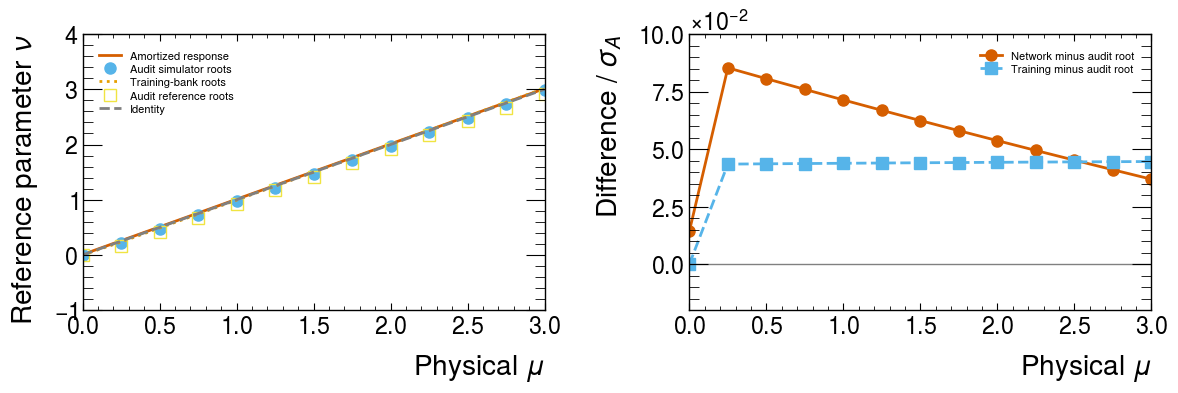

In [11]:
def bank_mean(bank, values):
    return values.mean() if bank['p'] is None else np.dot(bank['p'], values)

def population_score(nu, mu, processes):
    s, b = processes['signal'], processes['background']
    return (-LAM_S + mu * LAM_S * bank_mean(s, s['q'] / (1 + nu*s['q']))
            + LAM_B * bank_mean(b, b['q'] / (1 + nu*b['q'])))

def population_fit(mu, processes):
    if population_score(0, mu, processes) <= 0:
        return 0.0
    upper = max(1.0, mu)
    while population_score(upper, mu, processes) > 0:
        upper *= 2
    return brentq(lambda nu: population_score(nu, mu, processes), 0, upper)

def population_loglik(nu, mu, processes):
    s, b = processes['signal'], processes['background']
    return (-nu*LAM_S + mu*LAM_S*bank_mean(s, np.log1p(nu*s['q']))
            + LAM_B*bank_mean(b, np.log1p(nu*b['q'])))

def population_information(nu, mu, processes):
    s, b = processes['signal'], processes['background']
    return (mu*LAM_S*bank_mean(s, (s['q']/(1+nu*s['q']))**2)
            + LAM_B*bank_mean(b, (b['q']/(1+nu*b['q']))**2))

MU_ANCHORS = np.linspace(0, MU_MAX, 13)
response_rows = []
for mu in MU_ANCHORS:
    learned = float(response_value([mu])[0])
    audit = BANKS['audit']['simulator']
    root = population_fit(mu, audit)
    train_root = population_fit(mu, BANKS['train']['simulator'])
    sigma = population_information(root, mu, audit)**-0.5
    response_rows.append(dict(mu=mu, learned=learned, audit_root=root,
        train_root=train_root, reference_root=population_fit(mu, BANKS['audit']['reference']),
        sigma_A=sigma, error_over_sigma=(learned-root)/sigma,
        bank_shift_over_sigma=(train_root-root)/sigma,
        objective_gap=2*(population_loglik(root, mu, audit)-population_loglik(learned, mu, audit)),
        score_at_learned=population_score(learned, mu, audit)))
response_table = pd.DataFrame(response_rows)
response_table.to_csv(OUT / 'response_validation.csv', index=False)
display(response_table)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(MU_ANCHORS, response_table.learned, label='Amortized response')
axes[0].plot(MU_ANCHORS, response_table.audit_root, 'o', label='Audit simulator roots')
axes[0].plot(MU_ANCHORS, response_table.train_root, ':', label='Training-bank roots')
axes[0].plot(MU_ANCHORS, response_table.reference_root, 's', fillstyle='none', label='Audit reference roots')
axes[0].plot(MU_ANCHORS, MU_ANCHORS, '--', color='grey', label='Identity')
axes[0].set(xlabel=r'Physical $\mu$', ylabel=r'Reference parameter $\nu$')
axes[0].legend(fontsize=8)
axes[1].plot(MU_ANCHORS, response_table.error_over_sigma, 'o-', label='Network minus audit root')
axes[1].plot(MU_ANCHORS, response_table.bank_shift_over_sigma, 's--', label='Training minus audit root')
axes[1].axhline(0, color='grey', lw=1)
axes[1].set(xlabel=r'Physical $\mu$', ylabel=r'Difference / $\sigma_A$')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'response_validation.png', dpi=150)
plt.show()
assert response_table.learned.max() < NU_QUERY_MAX, 'Increase NU_QUERY_MAX and rerun for this deformation.'


## 3. Generate full experiments and exact teacher labels

For each physical design point $\mu$, simulator toys use signal mean $\mu\lambda_S$; reference toys use signal mean $g_\rho(\mu)\lambda_S$. Both use background mean $\lambda_B$. The Poisson counts fluctuate independently.

We fit **the same** reference likelihood to both sources and evaluate

$$\hat\nu(D)=\arg\max_{\nu\geq0}\ell_H(\nu;D),\qquad
T_\nu(D)=2[\ell_H(\hat\nu;D)-\ell_H(\nu;D)].$$

Each row stores the embedding, count, teacher estimator and several queried statistic values. Queries include $g_\rho(\mu)$, zero, the exact minimum, and random values in the configured query range. The validation and audit use fresh continuous queries, so they test interpolation rather than memorization of a grid. Whole experiments stay in a single split.

We generate one experiment at a time and discard its event indices after summation and fitting. This avoids storing a giant padded tensor. Nevertheless, drawing and labeling full experiments is still real computation. The acceleration comes afterward, when the cached embeddings are reused for head training and inference. At inference time, neither head receives the source or true $\mu$.


In [12]:
def draw_experiment(processes, generating_nu, rng):
    total_embedding = np.zeros(EMBED_DIM, dtype=float)
    q_parts = []
    counts = [rng.poisson(generating_nu * LAM_S), rng.poisson(LAM_B)]
    for process, count in zip(['signal', 'background'], counts):
        bank = processes[process]
        indices = draw_indices(bank, count, rng)
        total_embedding += bank['e'][indices].sum(axis=0, dtype=float)
        q_parts.append(bank['q'][indices])
    n = sum(counts)
    z = np.r_[float(n), total_embedding / n if n else total_embedding]
    return z, np.concatenate(q_parts)

def make_toy_table(split, count_per_source, seed):
    rng = np.random.default_rng(seed)
    records = []
    started = time.perf_counter()
    for domain, source in enumerate(DOMAINS):
        mu = rng.uniform(0, MU_MAX, count_per_source)
        # Deliberate endpoint examples, in addition to the continuous design.
        mu[:max(1, count_per_source//10)] = 0
        mu[-max(1, count_per_source//10):] = MU_MAX
        mapped = response_value(mu)
        for i in range(count_per_source):
            generating_nu = mapped[i] if source == 'reference' else mu[i]
            z, q = draw_experiment(BANKS[split][source], generating_nu, rng)
            fitted = ep.exact_fit(q, LAM_S)
            queries = rng.uniform(0, NU_QUERY_MAX, N_QUERY)
            queries[:3] = [mapped[i], 0, fitted]
            statistic = ep.exact_statistic(q, queries, LAM_S, nu_hat=fitted)
            records.append((z, fitted, queries, statistic, mu[i], domain))
            if (i+1) % max(1, count_per_source//5) == 0:
                print(f'{split}: {source} {i+1}/{count_per_source}')
    names = ['z', 'nu_hat', 'nu', 't', 'mu', 'domain']
    result = {name: np.asarray([row[j] for row in records]) for j, name in enumerate(names)}
    result['generation_seconds'] = np.asarray(time.perf_counter()-started)
    return result

TABLES = {}
for k, split in enumerate(['train', 'validation', 'audit']):
    TABLES[split] = cached_arrays(f'{split}_toys', lambda: make_toy_table(
        split, SIZES[f'toys_{split}'], SEED+500+k))
    table = TABLES[split]
    print(split, 'experiments:', len(table['z']),
          'mean N:', table['z'][:, 0].mean(),
          'generation seconds:', float(table['generation_seconds']),
          'fraction of MLEs above query range:', np.mean(table['nu_hat'] > NU_QUERY_MAX))
    assert np.min(table['t']) >= -1e-7
    assert np.max(np.abs(table['t'][:, 2])) < 1e-7


train: reference 300/1500
train: reference 600/1500
train: reference 900/1500
train: reference 1200/1500
train: reference 1500/1500
train: simulator 300/1500
train: simulator 600/1500
train: simulator 900/1500
train: simulator 1200/1500
train: simulator 1500/1500
train experiments: 3000 mean N: 153746.778 generation seconds: 278.80216713900154 fraction of MLEs above query range: 0.0
validation: reference 60/300
validation: reference 120/300
validation: reference 180/300
validation: reference 240/300
validation: reference 300/300
validation: simulator 60/300
validation: simulator 120/300
validation: simulator 180/300
validation: simulator 240/300
validation: simulator 300/300
validation experiments: 600 mean N: 153707.675 generation seconds: 45.51139479399899 fraction of MLEs above query range: 0.0
audit: reference 60/300
audit: reference 120/300
audit: reference 180/300
audit: reference 240/300
audit: reference 300/300
audit: simulator 60/300
audit: simulator 120/300
audit: simulator 1

### Fit the estimator and statistic heads

The estimator learns $\hat\nu$ from $z$. The statistic head learns $T_\nu$ from $(z,\nu)$. Both use the same frozen representation, with standardization fitted only on training embeddings. Their training targets come from numerical likelihood fits; there are no posterior-to-likelihood conversions.

The helper uses small multilayer perceptrons, a nonnegative output parameterization and a loss on the square root of $T$ to balance the minimum and larger statistic values. Validation loss selects the checkpoint. The direct statistic head is an approximation and is not forced to reproduce an exactly coherent likelihood curve; the scan plots below expose that error.

The reusable implementations are in [utils_extended_pairs.py](https://github.com/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/utils_extended_pairs.py). They use ordinary PyTorch training loops, with the mathematical objective kept separate from caching and plotting.


epoch   1: train=8.7351, val=7.4469
epoch  10: train=1.5194, val=1.5078
epoch  20: train=0.99946, val=1.0291
epoch  30: train=0.6294, val=0.65631
epoch  40: train=0.28787, val=0.31158
epoch  50: train=0.24425, val=0.26309
epoch  60: train=0.21726, val=0.25553
epoch  70: train=0.19331, val=0.2184
epoch  80: train=0.18197, val=0.20834
epoch  90: train=0.19971, val=0.22918
epoch 100: train=0.15413, val=0.18504
epoch 110: train=0.14403, val=0.16694
epoch 120: train=0.13676, val=0.15899


,source,mu_low,mu_high,toys,estimator_bias,estimator_rmse,statistic_bias,statistic_rmse,statistic_abs_error_95,teacher_boundary_fraction,fast_near_boundary_fraction
0,reference,0.0,0.5,67,0.012339,0.124139,-0.162123,0.502520,0.997556,0.492537,0.059701
1,reference,0.5,1.5,75,-0.084480,0.161029,-0.070346,0.560579,1.175334,0.093333,0.013333
2,reference,1.5,3.0,158,-0.077690,0.157346,-0.111776,0.640588,1.247837,0.000000,0.000000
3,simulator,0.0,0.5,64,0.007362,0.111448,-0.196165,0.419924,0.832375,0.421875,0.093750
4,simulator,0.5,1.5,85,-0.064360,0.135591,-0.094764,0.603477,1.177907,0.070588,0.000000
5,simulator,1.5,3.0,151,-0.036711,0.141833,-0.117016,0.641205,1.257714,0.000000,0.000000


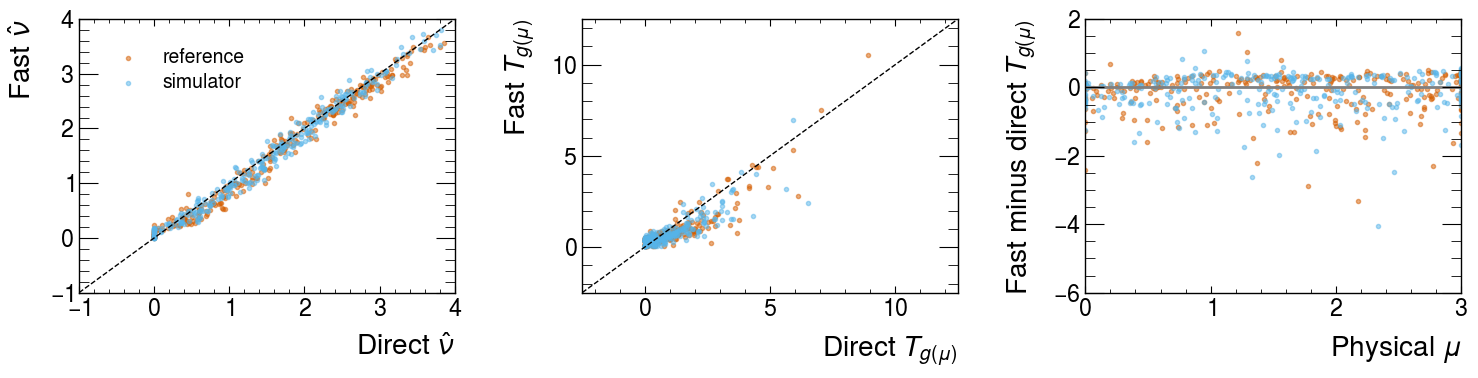

In [13]:
torch.manual_seed(SEED+6)
heads = ep.FastHeads(EMBED_DIM + 1, width=96)
head_history = cached_model('heads', heads, lambda: ep.train_heads(
    heads, TABLES['train'], TABLES['validation'], epochs=SIZES['heads_epochs'],
    batch_size=256, lr=1e-3, patience=15, seed=SEED+6, device=DEVICE))

audit = TABLES['audit']
hat_fast, t_fast = ep.predict_heads(heads, audit['z'], audit['nu'], device=DEVICE)
hat_error = hat_fast - audit['nu_hat']
t_error = t_fast - audit['t']
metric_rows = []
for d, source in enumerate(DOMAINS):
    for low, high in [(0, 0.5), (0.5, 1.5), (1.5, MU_MAX+1e-6)]:
        keep = (audit['domain']==d) & (audit['mu']>=low) & (audit['mu']<high)
        if not keep.any():
            continue
        de, dt = hat_error[keep], t_error[keep, 0]
        metric_rows.append(dict(source=source, mu_low=low, mu_high=min(high,MU_MAX),
            toys=int(keep.sum()), estimator_bias=de.mean(), estimator_rmse=np.sqrt(np.mean(de**2)),
            statistic_bias=dt.mean(), statistic_rmse=np.sqrt(np.mean(dt**2)),
            statistic_abs_error_95=np.quantile(np.abs(dt), .95),
            teacher_boundary_fraction=np.mean(audit['nu_hat'][keep]==0),
            fast_near_boundary_fraction=np.mean(hat_fast[keep]<0.01)))
metrics = pd.DataFrame(metric_rows)
display(metrics)
metrics.to_csv(OUT / 'head_validation.csv', index=False)
np.savez(OUT / 'audit_predictions.npz', nu_hat_fast=hat_fast, t_fast=t_fast)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for d, source in enumerate(DOMAINS):
    keep = audit['domain']==d
    axes[0].scatter(audit['nu_hat'][keep], hat_fast[keep], s=9, alpha=.5, label=source)
    axes[1].scatter(audit['t'][keep, 0], t_fast[keep, 0], s=9, alpha=.5, label=source)
    axes[2].scatter(audit['mu'][keep], t_error[keep, 0], s=9, alpha=.5, label=source)
for ax in axes[:2]:
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
axes[0].set(xlabel=r'Direct $\hat\nu$', ylabel=r'Fast $\hat\nu$')
axes[1].set(xlabel=r'Direct $T_{g(\mu)}$', ylabel=r'Fast $T_{g(\mu)}$')
axes[2].set(xlabel=r'Physical $\mu$', ylabel=r'Fast minus direct $T_{g(\mu)}$')
axes[2].axhline(0, color='grey')
axes[0].legend()
fig.tight_layout()
fig.savefig(OUT / 'head_validation.png', dpi=150)
plt.show()


### Boundary, tail and interpolation diagnostics

Average regression error can hide the most relevant failures. We therefore inspect the error at the exact likelihood minimum, near several representative statistic levels, and on previously unseen query values. The levels below are merely diagnostic locations; **we are not using them as calibrated cutoffs**.

The exact boundary $\hat\nu=0$ can carry nonzero probability. Report its frequency and the head's behavior separately. A smooth nonnegative approximation need not reproduce this atom exactly, which matters for the later distribution model.


,source,region,entries,mean_abs_error,p95_abs_error
0,reference,at exact minimum,300,0.313815,0.505287
1,reference,0 <= T < 1,402,0.257239,0.506233
2,reference,1 <= T < 2.71,260,0.712194,1.513537
3,reference,2.71 <= T < 3.84,128,1.218642,2.122064
4,reference,3.84 <= T < 8,318,1.740341,3.598387
5,reference,8 <= T < inf,992,2.423984,5.587131
6,simulator,at exact minimum,300,0.320570,0.496627
7,simulator,0 <= T < 1,423,0.258482,0.493617
8,simulator,1 <= T < 2.71,250,0.694463,1.312216
9,simulator,2.71 <= T < 3.84,112,1.286242,2.257187


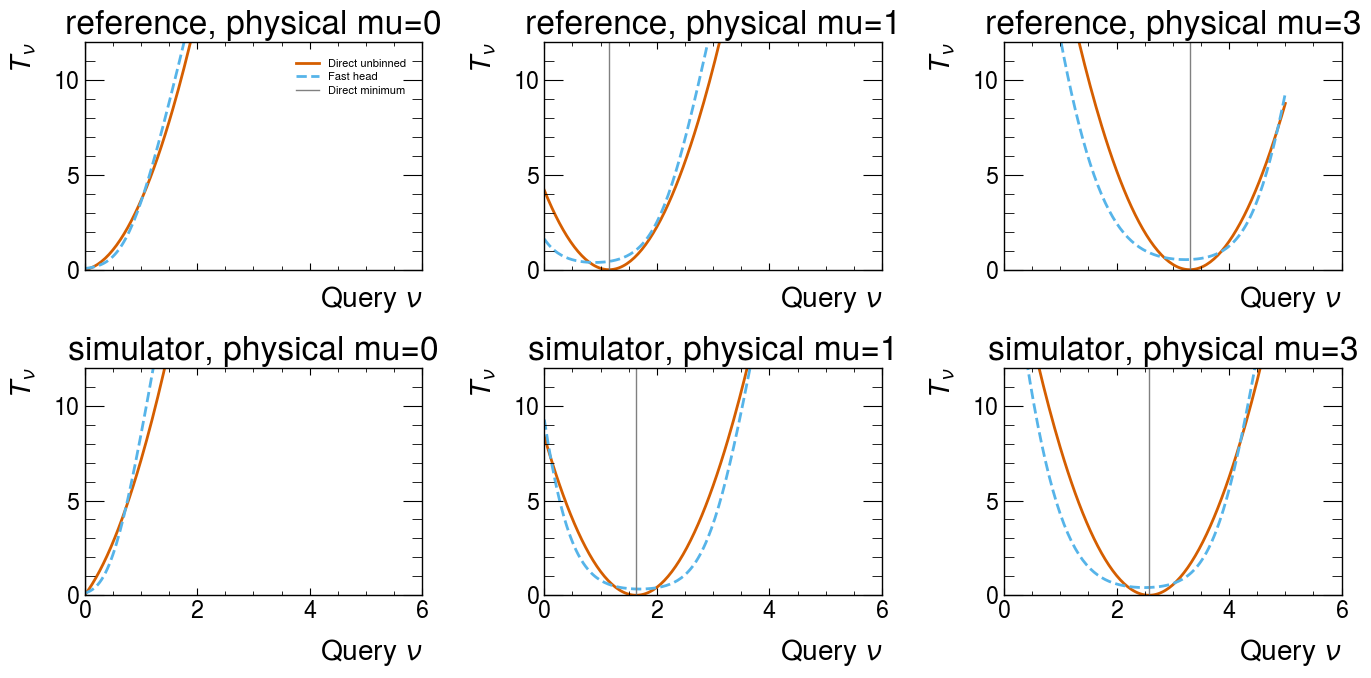

,source,mu,direct_mle,fast_mle,max_abs_scan_error
0,reference,0.0,0.000000,0.121824,4.845105
1,reference,1.0,1.150670,0.871579,3.052548
2,reference,3.0,3.302044,3.209733,4.397856
3,simulator,0.0,0.000000,0.019702,7.598736
4,simulator,1.0,1.633196,1.692976,2.011076
5,simulator,3.0,2.578929,2.506270,3.608438


In [14]:
diagnostics = []
for d, source in enumerate(DOMAINS):
    keep = audit['domain']==d
    diagnostics.append(dict(source=source, region='at exact minimum',
        entries=int(keep.sum()), mean_abs_error=np.abs(t_error[keep, 2]).mean(),
        p95_abs_error=np.quantile(np.abs(t_error[keep, 2]), .95)))
    # Exclude the deliberately supplied exact minima from query diagnostics.
    for low, high in [(0, 1), (1, 2.71), (2.71, 3.84), (3.84, 8), (8, np.inf)]:
        truth = audit['t'][keep][:, 3:]
        error = t_error[keep][:, 3:]
        selected = (truth>=low) & (truth<high)
        if selected.any():
            diagnostics.append(dict(source=source, region=f'{low:g} <= T < {high:g}',
                entries=int(selected.sum()), mean_abs_error=np.abs(error[selected]).mean(),
                p95_abs_error=np.quantile(np.abs(error[selected]), .95)))
display(pd.DataFrame(diagnostics))
pd.DataFrame(diagnostics).to_csv(OUT / 'statistic_regions.csv', index=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
scan_nu = np.linspace(0, NU_QUERY_MAX, 151)
scan_records = []
rng = np.random.default_rng(SEED+900)
for row, source in enumerate(DOMAINS):
    for col, mu in enumerate([0.0, 1.0, 3.0]):
        generating_nu = response_value([mu])[0] if source=='reference' else mu
        z, q = draw_experiment(BANKS['audit'][source], generating_nu, rng)
        fitted = ep.exact_fit(q, LAM_S)
        direct = ep.exact_statistic(q, scan_nu, LAM_S, nu_hat=fitted)
        predicted_hat, predicted = ep.predict_heads(heads, z[None], scan_nu[None], device=DEVICE)
        ax = axes[row, col]
        ax.plot(scan_nu, direct, label='Direct unbinned')
        ax.plot(scan_nu, predicted[0], '--', label='Fast head')
        ax.axvline(fitted, color='grey', lw=1, label='Direct minimum')
        ax.set(title=f'{source}, physical mu={mu:g}', ylabel=r'$T_\nu$', xlabel=r'Query $\nu$')
        ax.set_ylim(0, 12)
        scan_records.append(dict(source=source, mu=mu, direct_mle=fitted,
            fast_mle=float(predicted_hat[0]), max_abs_scan_error=float(np.max(np.abs(predicted[0]-direct)))))
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'unbinned_scans.png', dpi=150)
plt.show()
display(pd.DataFrame(scan_records))


### What did the learned representation add?

As a simple baseline, repeat the same head training using the observed count $N$ alone. This baseline sees the same experiments and teacher labels. Compare it with the learned embedding on the audit set. Improvement quantifies useful shape information retained by the encoder. If it does not improve, we should investigate representation training before adding calibration flows.

We also inspect estimator means against the population response. They need not coincide at finite event count, especially near the boundary. The response-map definition is unchanged by this comparison.


In [15]:
torch.manual_seed(SEED+7)
count_heads = ep.FastHeads(1, width=96)
count_train = dict(TABLES['train'], z=TABLES['train']['z'][:, :1])
count_val = dict(TABLES['validation'], z=TABLES['validation']['z'][:, :1])
count_history = cached_model('count_heads', count_heads, lambda: ep.train_heads(
    count_heads, count_train, count_val, epochs=SIZES['heads_epochs'],
    batch_size=256, lr=1e-3, patience=15, seed=SEED+7, device=DEVICE))
count_hat, count_t = ep.predict_heads(count_heads, audit['z'][:, :1], audit['nu'], device=DEVICE)
comparison = []
for d, source in enumerate(DOMAINS):
    keep = audit['domain']==d
    for label, estimated_hat, estimated_t in [('Count only', count_hat, count_t),
                                              ('Learned embedding + count', hat_fast, t_fast)]:
        comparison.append(dict(source=source, representation=label,
            estimator_rmse=np.sqrt(np.mean((estimated_hat[keep]-audit['nu_hat'][keep])**2)),
            statistic_rmse=np.sqrt(np.mean((estimated_t[keep,0]-audit['t'][keep,0])**2))))
display(pd.DataFrame(comparison))
pd.DataFrame(comparison).to_csv(OUT / 'count_baseline.csv', index=False)

endpoint_means = []
for d, source in enumerate(DOMAINS):
    for mu in [0.0, MU_MAX]:
        keep = (audit['domain']==d) & (audit['mu']==mu)
        values = audit['nu_hat'][keep]
        endpoint_means.append(dict(source=source, mu=mu, g=float(response_value([mu])[0]),
            mean_direct_estimator=values.mean(),
            mean_fast_estimator=hat_fast[keep].mean(),
            standard_error_direct=values.std(ddof=1)/np.sqrt(len(values))))
display(pd.DataFrame(endpoint_means))


epoch   1: train=8.2788, val=6.6252
epoch  10: train=1.6289, val=1.6283
epoch  20: train=1.1387, val=1.2213
epoch  30: train=0.86137, val=0.92474
epoch  40: train=0.49625, val=0.53876
epoch  50: train=0.44034, val=0.46904
epoch  60: train=0.3953, val=0.4857
epoch  70: train=0.36103, val=0.40378
epoch  80: train=0.34879, val=0.4226
epoch  90: train=0.34301, val=0.388
epoch 100: train=0.33496, val=0.42274


,source,representation,estimator_rmse,statistic_rmse
0,reference,Count only,0.276038,0.921276
1,reference,Learned embedding + count,0.151536,0.592519
2,simulator,Count only,0.280703,0.864225
3,simulator,Learned embedding + count,0.134105,0.589700


,source,mu,g,mean_direct_estimator,mean_fast_estimator,standard_error_direct
0,reference,0.0,0.008042,0.191415,0.210697,0.063653
1,reference,3.0,3.011863,3.027875,2.888088,0.075503
2,simulator,0.0,0.008042,0.228418,0.261968,0.056217
3,simulator,3.0,3.011863,2.767417,2.763085,0.085904


### Timing and a reusable inference function

Timing should separate the one-time preparation from repeated inference. We report cached-head time per experiment and direct fit/statistic time with the same number of queries. The cached timing excludes event encoding, whose total was reported above. For a new dataset, the reusable function below includes the necessary event encoding and count construction.

Its input is already PRESEL-selected reconstructed features in `FEATURES` order. It returns the reference-coordinate estimator and the statistic evaluated at the supplied physical hypotheses through the frozen response map. It does not return confidence intervals or calibrated $p$-values.


In [16]:
def synchronize():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

# Warm up before timing cached inference.
ep.predict_heads(heads, audit['z'][:10], audit['nu'][:10], device=DEVICE)
synchronize()
start = time.perf_counter()
for _ in range(10):
    ep.predict_heads(heads, audit['z'], audit['nu'], device=DEVICE)
synchronize()
head_seconds = (time.perf_counter()-start) / (10*len(audit['z']))
start = time.perf_counter()
ep.exact_statistic(q, np.linspace(0, NU_QUERY_MAX, N_QUERY), LAM_S)
direct_seconds = time.perf_counter()-start
print(f'Cached head: {head_seconds*1000:.3f} ms/experiment, {N_QUERY} queries')
print(f'Direct fit + {N_QUERY} queries, N={len(q):,}: {direct_seconds*1000:.3f} ms')

def infer_experiment(selected_x, physical_mu):
    event_embedding = ep.encode_events(encoder, np.asarray(selected_x, dtype=np.float32), device=DEVICE)
    n = len(event_embedding)
    mean = event_embedding.mean(0, dtype=float) if n else np.zeros(EMBED_DIM)
    z = np.r_[n, mean][None]
    mu = np.atleast_1d(physical_mu).astype(float)
    if np.any((mu < 0) | (mu > MU_MAX)):
        raise ValueError('Physical hypotheses must lie in the trained range.')
    nu = response_value(mu)
    fitted, statistic = ep.predict_heads(heads, z, nu[None], device=DEVICE)
    return dict(mu=mu, nu_test=nu, nu_hat=float(fitted[0]), t=statistic[0])

manifest = dict(run_id=RUN_ID, features=FEATURES, configuration='config.json',
    representation='pairs.pt', response='response.pt', heads='heads.pt',
    tables={split: f'{split}_toys.npz' for split in TABLES},
    statistic='T_nu = 2 [ell_H(nu_hat) - ell_H(nu)], queried at nu=g(mu)',
    calibration_performed=False)
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print('Saved models, compact toy tables and validation results in', OUT)


Cached head: 0.002 ms/experiment, 10 queries
Direct fit + 10 queries, N=154,311: 13.976 ms
Saved models, compact toy tables and validation results in saved_exercise13_extendedPAIRS/5f97501b6b87


## Reading the results before proceeding

The useful questions are:

1. Does pair pretraining beat the prior-only posterior prediction on independent events?
2. Does the learned response follow the direct population roots? How much of its audit error comes from the finite event banks?
3. Do the learned embeddings improve on the count-only baseline at the nominal event count?
4. Are estimator and statistic errors small in both domains, including the boundary and relevant tails? Do individual scans have the right shape?
5. Is the computational gain large enough once event encoding and label generation are accounted for?

These are diagnostics, not hard-coded success assertions. A poor plot is a useful result: first improve the corresponding stage and rerun with an independent audit before proceeding. `quick` is particularly unlikely to support precise conclusions. For a meaningful bank-convergence study, increase the bank sizes as well as the number of experiments.

The output directory contains the frozen models, the train/validation/audit embedding tables, the response-root comparison, and the head diagnostics. The audit has now been inspected; a later coverage study needs fresh simulation. The next notebook will freeze the chosen statistic, generate separate reference and simulator calibration ensembles, and learn their conditional distributions. No change to the statistic should be made after those calibration/audit samples are used without regenerating the relevant validation.

For multiple parameters, the future response is a joint population fit and the statistic requires constrained nuisance fits. The same representation and caching idea can be tested there, but this scalar exercise does not establish that those harder steps are solved.
